# Stage 3 — Fine-tuning SHViT-S4 on Food-101

This notebook fine-tunes a pretrained SHViT model on Food-101 using `finetune_shvit_food101.py`.

**Before running:** `Runtime → Change runtime type → T4 GPU`

### What this notebook does
1. Verifies GPU, clones repos, installs deps
2. Downloads SHViT-S4 pretrained weights
3. Runs the fine-tuning script for 30 epochs
4. Plots training curves from the CSV log

### Key design decisions (matching original SHViT paper)
| Setting | Value | Source |
|---|---|---|
| Augmentation | RandAugment `rand-m9-mstd0.5-inc1` + RandomErasing p=0.25 | SHViT paper |
| Mixup | alpha=0.8 | SHViT paper |
| CutMix | alpha=1.0 | SHViT paper |
| Label smoothing | 0.1 | SHViT paper |
| Training FP | **Full FP32** forward pass | Matches engine.py (commented-out autocast) |
| Eval FP | AMP autocast | Matches engine.py `evaluate()` |
| Grad clip | norm 0.02 | SHViT paper |
| Optimizer | AdamW, wd=0.025 | SHViT paper |
| LR schedule | Cosine + 5-epoch warmup | SHViT paper |

## 0. GPU check

In [1]:
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-40GB


## 1. (Optional) Mount Drive

Persist the dataset, weights, and checkpoints across sessions.

In [2]:
USE_DRIVE = True

# All artifacts (dataset, pretrained weights, fine-tune outputs, local SSD
# copies) live under a single root directory called CV_Research_Paper_Food101.
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CV_Research_Paper_Food101'
else:
    BASE_DIR = '/content/CV_Research_Paper_Food101'

DATA_ROOT   = f'{BASE_DIR}/food101_data'
WEIGHTS_DIR = f'{BASE_DIR}/shvit_weights'
OUTPUT_DIR  = f'{BASE_DIR}/Stage 3: fine-tuning SHViT'

WEIGHTS_PATH = f'{WEIGHTS_DIR}/shvit_s4.pth'

import os
for p in [DATA_ROOT, WEIGHTS_DIR, OUTPUT_DIR]:
    os.makedirs(p, exist_ok=True)
print('Base      :', BASE_DIR)
print('Data      :', DATA_ROOT)
print('Weights   :', WEIGHTS_DIR)
print('Output    :', OUTPUT_DIR)

Mounted at /content/drive
Base      : /content/drive/MyDrive/CV_Research_Paper_Food101
Data      : /content/drive/MyDrive/CV_Research_Paper_Food101/food101_data
Weights   : /content/drive/MyDrive/CV_Research_Paper_Food101/shvit_weights
Output    : /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 3: fine-tuning SHViT


In [3]:
# ---------------------------------------------------------------------------
# Robust Food-101 setup.
#
# The freezes/crashes come from heavy I/O on the Google Drive FUSE mount:
# downloading + extracting + copying the 101,000 small Food-101 image files
# through Drive is extremely slow and routinely stalls / kills the runtime.
#
# Fix: do ALL extraction and every training read on the LOCAL SSD, and persist
# only the single ~5 GB tarball on Drive (Drive handles one big file fine).
# torchvision verifies the tarball's MD5, so a corrupt/partial download is
# re-fetched cleanly instead of crashing later.
# ---------------------------------------------------------------------------
import os, shutil, time, torchvision

SPLIT_ID = '1QK0tGi096I0Ba6kggatX1ee6dJFIcEJl'

def setup_food101(local_data, drive_data=None):
    """Prepare Food-101 on local SSD; persist only the single ~5 GB tarball on
    Drive. Avoids extracting/copying 101k small files over the Drive FUSE mount
    (the cause of the freezes/crashes). Returns the local data root."""
    os.makedirs(local_data, exist_ok=True)
    local_tgz = f'{local_data}/food-101.tar.gz'
    drive_tgz = f'{drive_data}/food-101.tar.gz' if drive_data else None

    def have_images(root):
        d = f'{root}/food-101/images'
        return os.path.isdir(d) and len(os.listdir(d)) == 101

    # 1) Seed the local tarball from the Drive cache (one big-file copy is far
    #    more reliable than copying the extracted 101k-file tree).
    if (not have_images(local_data) and not os.path.exists(local_tgz)
            and drive_tgz and os.path.exists(drive_tgz)):
        print('Restoring cached food-101.tar.gz from Drive ...')
        t0 = time.time(); shutil.copy(drive_tgz, local_tgz)
        print(f'  done in {time.time()-t0:.0f}s')

    # 2) Download (if needed) + MD5-verify + extract, all LOCALLY.
    print('Preparing Food-101 locally (download/verify/extract) ...')
    t0 = time.time()
    torchvision.datasets.Food101(root=local_data, split='train', download=True)
    torchvision.datasets.Food101(root=local_data, split='test',  download=True)
    print(f'  ready in {time.time()-t0:.0f}s')
    assert have_images(local_data), 'Food-101 not fully extracted'

    # 3) Cache the verified tarball back to Drive for future sessions.
    if drive_tgz and not os.path.exists(drive_tgz) and os.path.exists(local_tgz):
        os.makedirs(drive_data, exist_ok=True)
        print('Caching tarball to Drive (one big file) ...')
        t0 = time.time(); shutil.copy(local_tgz, drive_tgz)
        print(f'  cached in {time.time()-t0:.0f}s')

    # 4) Zhou split file -> local food-101 dir (cache on Drive too).
    split_path  = f'{local_data}/food-101/split_zhou_Food101.json'
    drive_split = f'{drive_data}/food-101/split_zhou_Food101.json' if drive_data else None
    if not os.path.exists(split_path):
        if drive_split and os.path.exists(drive_split):
            shutil.copy(drive_split, split_path)
        else:
            os.system('pip install -q gdown')
            os.system(f'gdown "https://drive.google.com/uc?id={SPLIT_ID}" -O "{split_path}"')
            if drive_split:
                os.makedirs(os.path.dirname(drive_split), exist_ok=True)
                shutil.copy(split_path, drive_split)
    assert os.path.exists(split_path), 'split_zhou_Food101.json missing'
    print('Zhou split present:', split_path)
    return local_data

DATA_ROOT = setup_food101('/content/CV_Research_Paper_Food101/food101_data',
                          DATA_ROOT if USE_DRIVE else None)
print('DATA_ROOT now (local SSD):', DATA_ROOT)

Restoring cached food-101.tar.gz from Drive ...
  done in 116s
Preparing Food-101 locally (download/verify/extract) ...
  ready in 56s
Zhou split present: /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
DATA_ROOT now (local SSD): /content/CV_Research_Paper_Food101/food101_data


## 2. Clone repos and install dependencies

In [4]:
import os

# Clone SHViT (provides the model architecture)
if not os.path.isdir('/content/SHViT'):
    !git clone https://github.com/ysj9909/SHViT.git /content/SHViT

# Clone our project repo to get the fine-tuning script and helpers
REPO = '/content/Vision_Project_spring_26'
BRANCH = 'Vision_Project_spring_26_Food101'
if not os.path.isdir(REPO):
    !git clone -b {BRANCH} \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git \
        {REPO}

import shutil
for fname in [
    'Stage 3: fine-tuning SHViT/finetune_shvit_food101.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
]:
    shutil.copy(f'{REPO}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))

# Copy the tip_datasets package (Tip-Adapter preprocessing + Zhou split loader).
if os.path.isdir('/content/tip_datasets'):
    shutil.rmtree('/content/tip_datasets')
shutil.copytree(f'{REPO}/tip_datasets', '/content/tip_datasets')
print('Copied: tip_datasets/')

Cloning into '/content/SHViT'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 183 (delta 84), reused 82 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 168.52 KiB | 11.23 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 1223, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 1223 (delta 108), reused 109 (delta 97), pack-reused 1087 (from 3)
Receiving objects: 100% (1223/1223), 543.97 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (620/620), done.
Copied: finetune_shvit_food101.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: tip_datasets/


In [5]:
# Install SHViT deps. timm must be pinned to 0.5.4 and installed --no-deps
# to avoid downgrading Colab's PyTorch. scikit-image / fvcore / yacs / onnx
# from SHViT's requirements.txt are NOT needed by our fine-tuning wrapper —
# scikit-image==0.19.3 in particular has no wheels for Python 3.12 and would
# fail to build from source.
!pip install -q timm==0.5.4 --no-deps
!pip install -q einops==0.4.1 easydict
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 32.2 MB/s eta 0:00:00
Dependencies installed.


## 3. Download SHViT-S4 pretrained weights

In [6]:
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(WEIGHTS_PATH):
    !wget -q --show-progress \
        https://github.com/ysj9909/SHViT/releases/download/v1.0/shvit_s4.pth \
        -O {WEIGHTS_PATH}
size_mb = os.path.getsize(WEIGHTS_PATH) / 1e6
print(f'Checkpoint: {size_mb:.1f} MB  ->  {WEIGHTS_PATH}')

Checkpoint: 266.7 MB  ->  /content/drive/MyDrive/CV_Research_Paper_Food101/shvit_weights/shvit_s4.pth


## 4. Fine-tune SHViT-S4 on Food-101

Food-101 is ~5 GB and downloaded automatically on the first run.

### Estimated runtime on T4
Each epoch: ~5-7 min (75k train images, batch 64, full FP32 forward).  
30 epochs ≈ **2.5–3.5 hours** — use `--epochs 5` first to smoke-test.

> **Tip:** Mount Drive (Cell 1) so checkpoints survive session expiry.

In [7]:
# Quick smoke-test: 2 epochs to verify everything runs
!python /content/finetune_shvit_food101.py \
    --shvit-dir  /content/SHViT \
    --finetune   "{WEIGHTS_PATH}" \
    --data-root  "{DATA_ROOT}" \
    --output-dir "{OUTPUT_DIR}" \
    --epochs 2 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8

Model: shvit_s4   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/shvit_weights/shvit_s4.pth
  Loaded tensors         : 633/635
  Head reinitialized     : ['head.l.bias', 'head.l.weight']
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 2 epochs (starting at 0)
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/2] lr=2.00e-05  train=4.5610  val=4.4565  top1=10.62%  top5=25.93%  (140s)
  -> new best (10.62%), saved to /content/drive/MyDrive/CV_Research_Pape

In [8]:
# Train all 4 SHViT variants sequentially.
# Order: S4 first (largest, do while you're awake to check it works),
#        then S3, S2, S1. Each gets its own output subfolder.

MODELS = ['shvit_s4', 'shvit_s3', 'shvit_s2', 'shvit_s1']

# Per-model weight decay from the SHViT paper.
# (Paper Table 7: S1=0.025, S2=0.032, S3=0.035, S4=0.05)
WEIGHT_DECAY = {
    'shvit_s1': 0.025,
    'shvit_s2': 0.032,
    'shvit_s3': 0.035,
    'shvit_s4': 0.050,
}

for model_name in MODELS:
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'

    # Download pretrained weights for this variant if missing
    if not os.path.exists(weights_path):
        print(f'\n=== Downloading {model_name} pretrained weights ===')
        !wget -q --show-progress \
            https://github.com/ysj9909/SHViT/releases/download/v1.0/{model_name}.pth \
            -O {weights_path}

    print(f'\n{"="*60}')
    print(f'Training {model_name}  (wd={WEIGHT_DECAY[model_name]})')
    print(f'{"="*60}')

    # Data preprocessing (Tip-Adapter: BICUBIC resize + CLIP normalize, no
    # augmentation) is owned by augmentation.py + the tip_datasets package.

    !python /content/finetune_shvit_food101.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   "{weights_path}" \
        --data-root  "{DATA_ROOT}" \
        --output-dir "{model_output_dir}" \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

    print(f'\n=== Finished {model_name} ===\n')

print('All 4 SHViT variants done.')


Training shvit_s4  (wd=0.05)
Model: shvit_s4   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/shvit_weights/shvit_s4.pth
  Loaded tensors         : 633/635
  Head reinitialized     : ['head.l.bias', 'head.l.weight']
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 30 epochs (starting at 0)
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/30] lr=2.00e-05  train=4.5512  val=4.4589  top1=10.68%  top5=25.71%  (139s)
  -> new best (10.68%), saved to /conten

In [9]:
# Resume from a checkpoint if the session was interrupted
# !python /content/finetune_shvit_food101.py \
#     --shvit-dir  /content/SHViT \
#     --data-root  "{DATA_ROOT}" \
#     --output-dir "{OUTPUT_DIR}" \
#     --resume     {OUTPUT_DIR}/checkpoint_010.pth \
#     --epochs 30 \
#     --batch-size 64 \
#     --lr 1e-4 \
#     --num-workers 8

In [10]:
import os, urllib.request

# Recovery cell for the SHViT pretrained weights (shvit_s1..s4).
# Re-downloads ONLY variants whose file is missing or truncated (the
# original failure mode was a 0-byte file; genuine checkpoints are
# 100-300 MB, so anything under 100 MB is treated as broken).
#
# Side-effect: populates MODELS_TO_REDO with every variant we actually had
# to recover, so the next cell only retrains those. A healthy file leaves
# MODELS_TO_REDO empty, making the retrain cell a no-op.
MODELS_TO_REDO = []
MIN_VALID_MB = 100  # genuine file is ~229 MB

def _recover(model_name):
    path = f'{WEIGHTS_DIR}/{model_name}.pth'
    url  = f'https://github.com/ysj9909/SHViT/releases/download/v1.0/{model_name}.pth'

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        if size_mb >= MIN_VALID_MB:
            print(f'{model_name}.pth looks healthy ({size_mb:.2f} MB) - skipping recovery.')
            return False
        print(f'{model_name}.pth looks broken ({size_mb:.2f} MB) - re-downloading.')
        os.remove(path)
    else:
        print(f'{model_name}.pth not found - downloading.')

    os.makedirs(WEIGHTS_DIR, exist_ok=True)
    print(f'  from {url}')
    urllib.request.urlretrieve(url, path)
    print(f'  done: {os.path.getsize(path)/1e6:.2f} MB')
    return True

# Check all four SHViT variants
for _name in ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']:
    if _recover(_name):
        MODELS_TO_REDO.append(_name)

print('\nMODELS_TO_REDO =', MODELS_TO_REDO)

shvit_s1.pth looks healthy (102.12 MB) - skipping recovery.
shvit_s2.pth looks healthy (184.67 MB) - skipping recovery.
shvit_s3.pth looks healthy (229.01 MB) - skipping recovery.
shvit_s4.pth looks healthy (266.73 MB) - skipping recovery.

MODELS_TO_REDO = []


In [11]:
# Retrain every variant that the recovery cell (Cell 15) actually had to
# re-download. If MODELS_TO_REDO is empty, nothing happens.
if not MODELS_TO_REDO:
    print('No variants need retraining (MODELS_TO_REDO is empty).')

for model_name in MODELS_TO_REDO:
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'

    !python /content/finetune_shvit_food101.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   "{weights_path}" \
        --data-root  "{DATA_ROOT}" \
        --output-dir "{model_output_dir}" \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

No variants need retraining (MODELS_TO_REDO is empty).


## 5. Evaluate the best checkpoint

In [12]:
MODEL = 'shvit_s4'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  "{DATA_ROOT}" \
    --output-dir "{MODEL_DIR}" \
    --eval

Model: shvit_s4   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 3: fine-tuning SHViT/shvit_s4/best.pth
  Loaded tensors         : 635/635
  Head reinitialized     : []
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 71.31%   top-5: 88.90%


In [13]:
MODEL = 'shvit_s3'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  "{DATA_ROOT}" \
    --output-dir "{MODEL_DIR}" \
    --eval

Model: shvit_s3   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 3: fine-tuning SHViT/shvit_s3/best.pth
  Loaded tensors         : 521/521
  Head reinitialized     : []
Trainable parameters: 13,841,622
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 70.70%   top-5: 88.57%


In [14]:
MODEL = 'shvit_s2'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  "{DATA_ROOT}" \
    --output-dir "{MODEL_DIR}" \
    --eval

Model: shvit_s2   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 3: fine-tuning SHViT/shvit_s2/best.pth
  Loaded tensors         : 471/471
  Head reinitialized     : []
Trainable parameters: 11,079,421
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 67.77%   top-5: 87.25%


In [15]:
MODEL = 'shvit_s1'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   "{MODEL_DIR}/best.pth" \
    --data-root  "{DATA_ROOT}" \
    --output-dir "{MODEL_DIR}" \
    --eval

Model: shvit_s1   Device: cuda
Reading split from /content/CV_Research_Paper_Food101/food101_data/food-101/split_zhou_Food101.json
Zhou split: 50,500 train  20,200 val
Pretrained weights loaded from /content/drive/MyDrive/CV_Research_Paper_Food101/Stage 3: fine-tuning SHViT/shvit_s1/best.pth
  Loaded tensors         : 471/471
  Head reinitialized     : []
Trainable parameters: 6,042,229
/content/finetune_shvit_food101.py:346: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:262: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 65.38%   top-5: 86.10%


## 6. Plot training curves

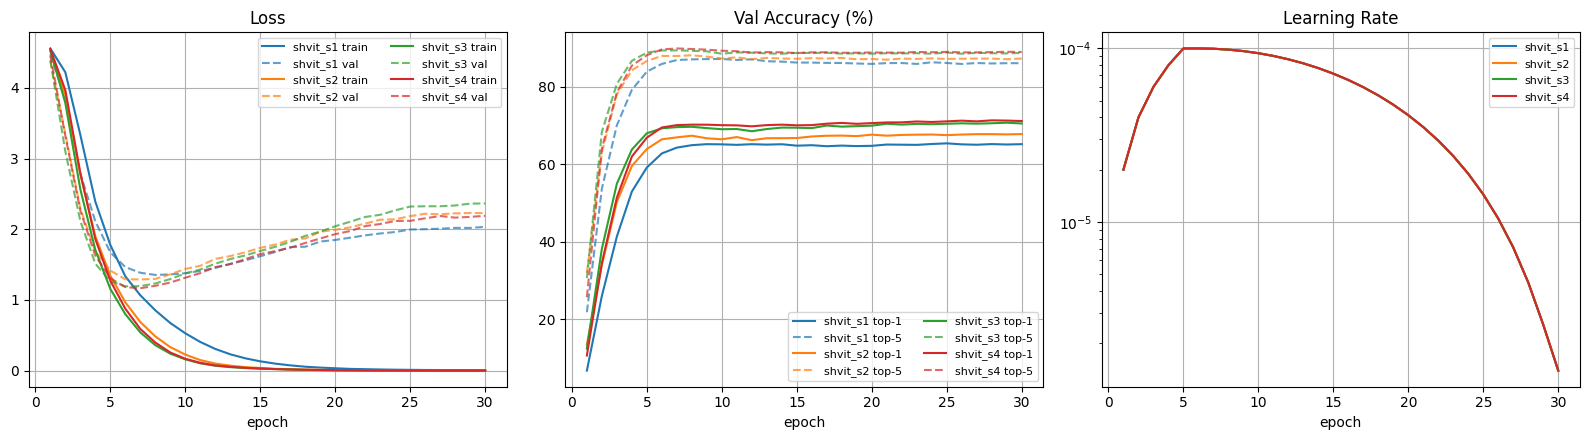


Best val accuracy per model:
model           top-1    top-5  epoch
shvit_s1       65.38%   86.10%     25
shvit_s2       67.77%   87.25%     30
shvit_s3       70.70%   88.57%     29
shvit_s4       71.31%   88.90%     28


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']
COLORS = {'shvit_s1': 'tab:blue', 'shvit_s2': 'tab:orange',
          'shvit_s3': 'tab:green', 'shvit_s4': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

summary = []
for model_name in MODELS:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        print(f'[skip] no log for {model_name}')
        continue

    df = pd.read_csv(csv_path)
    color = COLORS[model_name]

    # Loss (train solid, val dashed)
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train', color=color)
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val',
                 color=color, linestyle='--', alpha=0.7)

    # Accuracy (top-1 solid, top-5 dashed)
    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1', color=color)
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5',
                 color=color, linestyle='--', alpha=0.7)

    # LR schedule
    axes[2].plot(df['epoch'], df['lr'].astype(float), label=model_name, color=color)

    # Track best for the summary line
    best = df.loc[df['val_top1'].idxmax()]
    summary.append((model_name, best['val_top1']*100, best['val_top5']*100, int(best['epoch'])))

axes[0].set_title('Loss');           axes[0].set_xlabel('epoch')
axes[0].legend(fontsize=8, ncol=2);  axes[0].grid(True)

axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('epoch')
axes[1].legend(fontsize=8, ncol=2);    axes[1].grid(True)

axes[2].set_title('Learning Rate');    axes[2].set_xlabel('epoch')
axes[2].set_yscale('log');             axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_all.png', dpi=120)
plt.show()

# Summary table
print('\nBest val accuracy per model:')
print(f'{"model":<12} {"top-1":>8} {"top-5":>8} {"epoch":>6}')
for name, t1, t5, ep in summary:
    print(f'{name:<12} {t1:>7.2f}% {t5:>7.2f}% {ep:>6}')